# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

In [3]:
def plot_modified_df(df_cut):
    """
    Plots the modified DataFrame with adjusted time steps.

    Parameters:
    df_cut (pd.DataFrame): The modified DataFrame with adjusted time steps.

    Returns:
    None
    """
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'], label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'], label='Normal Force (Fz)', alpha=0.7)
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Modified Tangential vs Normal Force (Adjusted Timesteps)')
    plt.grid()
    plt.show()

<font size="6">Schieferstein 60°</font>

<font size="6">Test 1: (failed data logging)</font>

In [ ]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_60_5N//log_202405241720.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 1059
Average Fx in the averaging interval [50:1109]: 5.146276122427302
Average Fz in the averaging interval [50:1109]: 1.831260270505046
Maximum Fz in the plotting interval [50:None]: 3.6946207682291665 at timestep 1090
Time step where Fx drops below 1: 1109


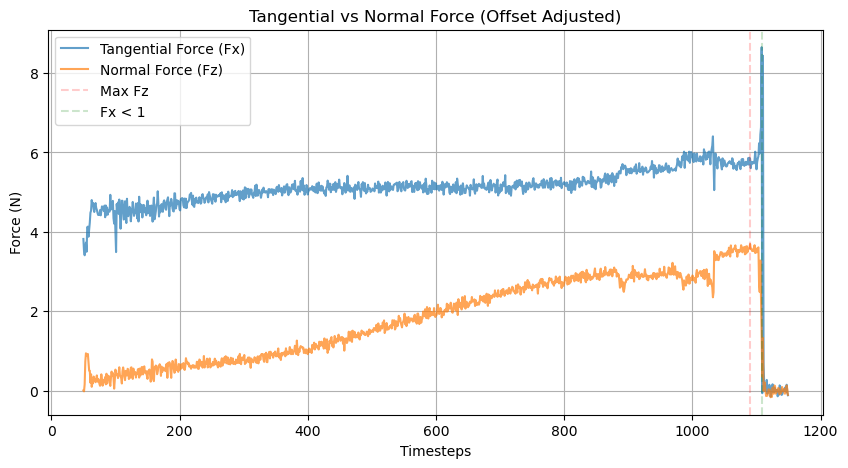

In [18]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_60_5N//log_202405241722.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=50, cut_2=None, avg_end=1109, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 489
Average Fx in the averaging interval [425:914]: 4.839523006509419
Average Fz in the averaging interval [425:914]: 0.773625847752109
Maximum Fz in the plotting interval [425:960]: 1.3603719075520833 at timestep 901
Time step where Fx drops below 1: 914


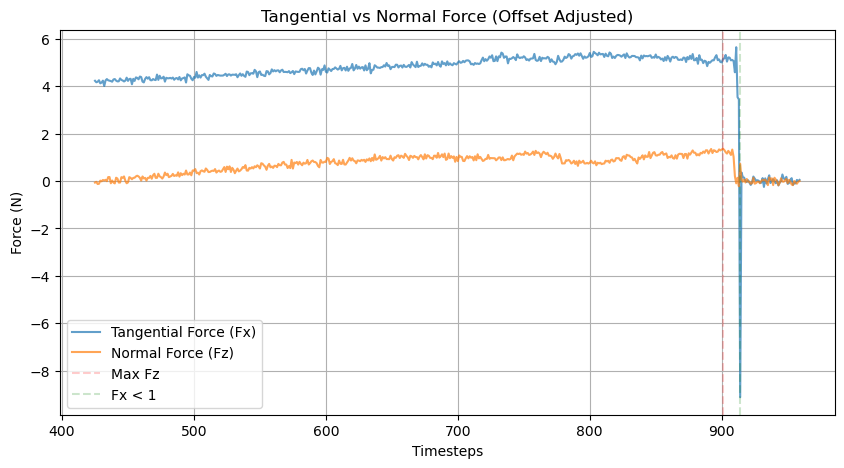

In [27]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_60_5N//log_202405241723.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=425, cut_2=960, avg_end=914, offset_position='beginning', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 362
Average Fx in the averaging interval [1253:1615]: 4.547361489290691
Average Fz in the averaging interval [1253:1615]: 0.8062574635992173
Maximum Fz in the plotting interval [1253:None]: 1.6239461263020833 at timestep 1600
Time step where Fx drops below 1: 1615


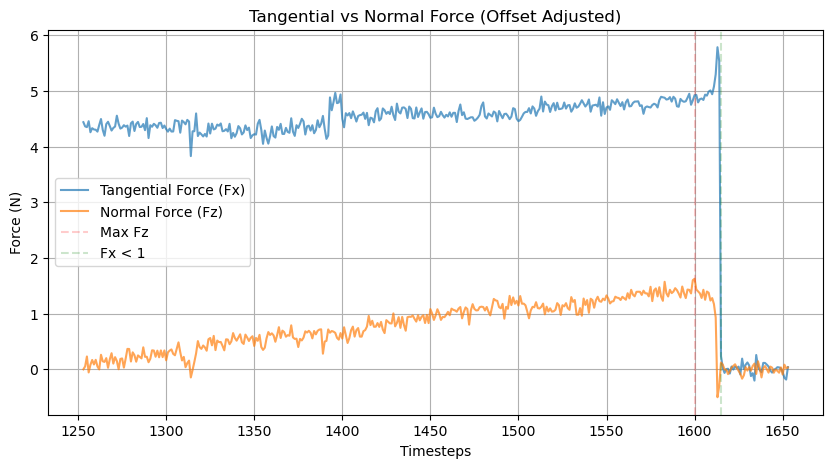

In [31]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_60_5N//log_202405241724.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=1253, cut_2=None, avg_end=1615, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 585
Average Fx in the averaging interval [816:1401]: 5.021777489654019
Average Fz in the averaging interval [816:1401]: 1.2229066506410255
Maximum Fz in the plotting interval [816:None]: 2.1289998372395833 at timestep 1389
Time step where Fx drops below 1: 1401


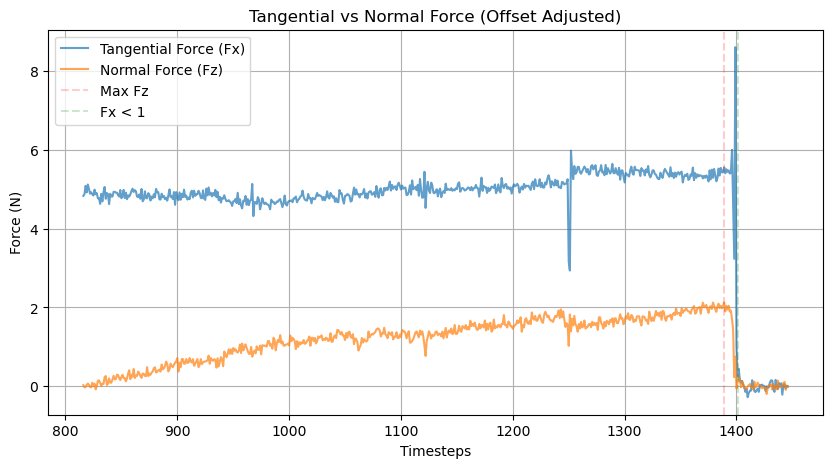

In [38]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_60_5N//log_202405241725.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=816, cut_2=None, avg_end=1401, offset_position='end', offset_length=15)

<font size="6">Test 6a: (partially worked)</font>

Length from cut_1 to avg_end: 126
Average Fx in the averaging interval [927:1053]: 4.273419054727706
Average Fz in the averaging interval [927:1053]: 0.22669493660094248
Maximum Fz in the plotting interval [927:1070]: 1.223291015625 at timestep 1053
Time step where Fx drops below 1: 1053


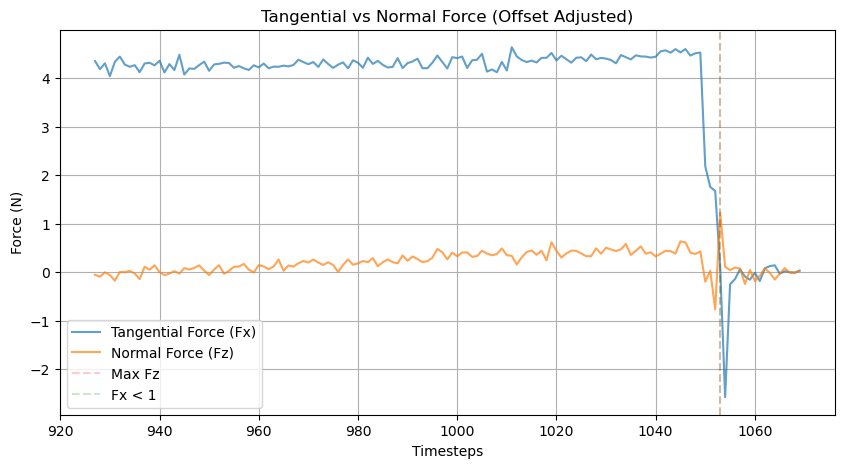

In [53]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_60_5N//log_202405241726.csv"
df = pd.read_csv(data)
test_6a, end_6a = plot_forces(df, cut_1=927, cut_2=1070, avg_end=1053, offset_position='end', offset_length=15)

<font size="6">Test 6b: (worked)</font>

Length from cut_1 to avg_end: 609
Average Fx in the averaging interval [1300:1909]: 4.1858484169532515
Average Fz in the averaging interval [1300:1909]: 1.0569622973111659
Maximum Fz in the plotting interval [1300:None]: 1.932763671875 at timestep 1885
Time step where Fx drops below 1: 1709


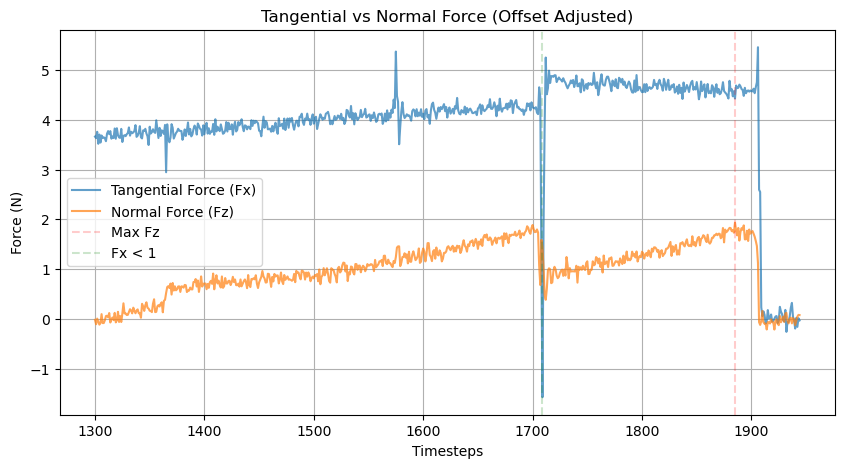

In [56]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_60_5N//log_202405241726.csv"
df = pd.read_csv(data)
test_6b, end_6b = plot_forces(df, cut_1=1300, cut_2=None, avg_end=1909, offset_position='end', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 647
Average Fx in the averaging interval [975:1622]: 5.158273803272669
Average Fz in the averaging interval [975:1622]: 1.4177483567990081
Maximum Fz in the plotting interval [975:None]: 2.769095865885417 at timestep 1613
Time step where Fx drops below 1: 1622


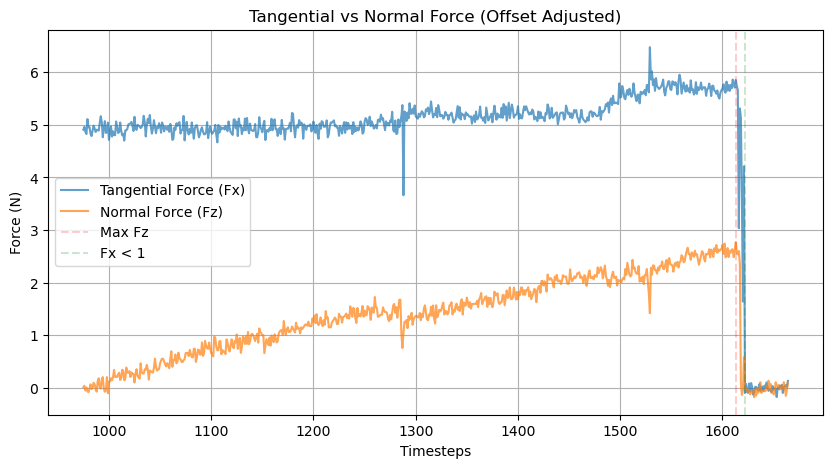

In [60]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_60_5N//log_202405241728.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=975, cut_2=None, avg_end=1622, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 764
Average Fx in the averaging interval [860:1624]: 5.03810264656473
Average Fz in the averaging interval [860:1624]: 1.442148487563741
Maximum Fz in the plotting interval [860:None]: 2.798958333333333 at timestep 1481
Time step where Fx drops below 1: 982


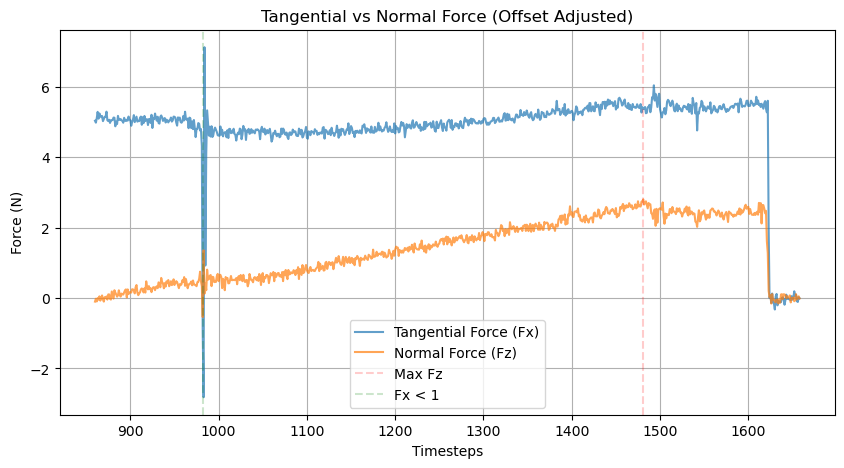

In [70]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_60_5N//log_202405241731.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=860, cut_2=None, avg_end=1624, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 782
Average Fx in the averaging interval [620:1402]: 5.313486228350992
Average Fz in the averaging interval [620:1402]: 1.6966194068277787
Maximum Fz in the plotting interval [620:None]: 3.038680013020833 at timestep 1329
Time step where Fx drops below 1: 1402


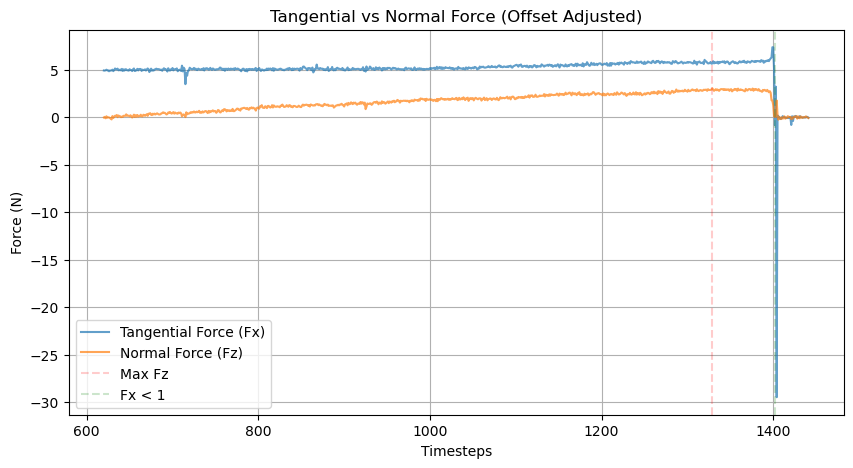

In [78]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_60_5N//log_202405241733.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=620, cut_2=None, avg_end=1402, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 484
Average Fx in the averaging interval [400:884]: 5.1128930486595
Average Fz in the averaging interval [400:884]: 0.4689857251716383
Maximum Fz in the plotting interval [400:901]: 1.2994425455729166 at timestep 855
Time step where Fx drops below 1: 884


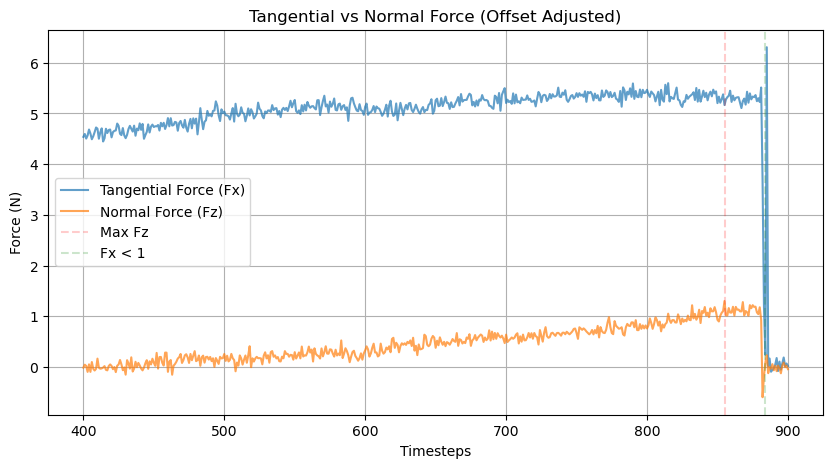

In [85]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_60_5N//log_202405241734.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=400, cut_2=901, avg_end=884, offset_position='beginning', offset_length=15)

<font size="6">Test 11: (worked)</font>

Length from cut_1 to avg_end: 913
Average Fx in the averaging interval [430:1343]: 5.3119203366603065
Average Fz in the averaging interval [430:1343]: 2.099234486775226
Maximum Fz in the plotting interval [430:None]: 3.678857421875 at timestep 1312
Time step where Fx drops below 1: 1343


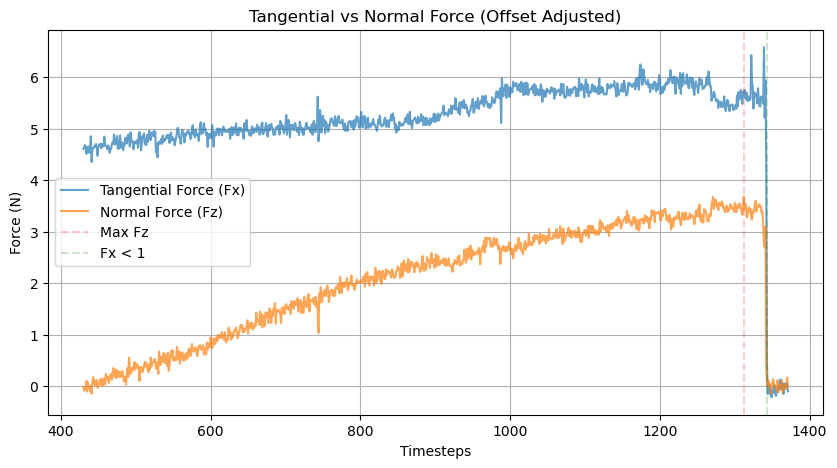

In [90]:
data = "../raw_data/Gripper Test Microspines Angles//Schieferstein_60_5N//log_202405241735.csv"
df = pd.read_csv(data)
test_11, end_11 = plot_forces(df, cut_1=430, cut_2=None, avg_end=1343, offset_position='end', offset_length=15)

In [91]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [95]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//60//Schieferstein_60_stats.csv", index=False)

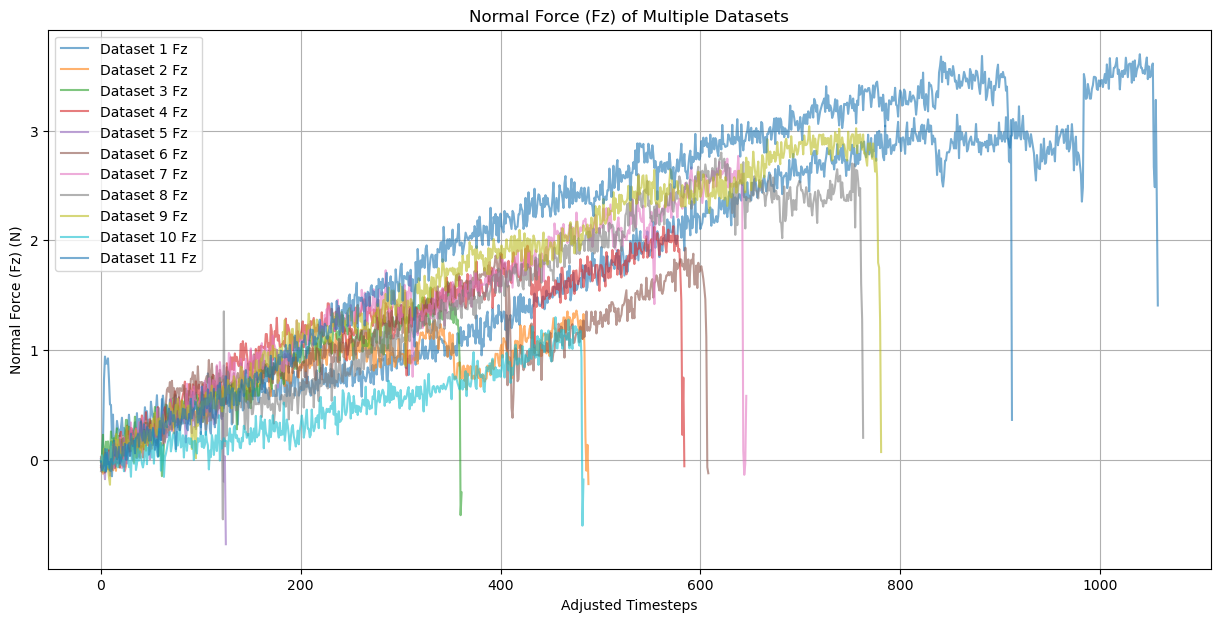

Average of maximum Fz forces: 2.269144324100379
Standard deviation of maximum Fz forces: 0.9595590901145743
Average of average Fz forces: 1.1856767208678998
Standard deviation of average Fz forces: 0.5557185162272189
Average of average Fx forces: 4.90444378573369
Standard deviation of average Fx forces: 0.3787110183771096


In [96]:
tests = [test_2, test_3, test_4, test_5, test_6a, test_6b, test_7, test_8, test_9, test_10, test_11]
ends = [end_2, end_3, end_4, end_5, end_6a, end_6b, end_7, end_8, end_9, end_10, end_11]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [97]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//60//Schieferstein_60"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)